In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path
import matplotlib.cm as cm
from matplotlib.patches import Polygon, Patch, Rectangle
from scipy.spatial import ConvexHull
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.metrics import pairwise_distances
from scipy import optimize
from collections import defaultdict, OrderedDict

In [2]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot" #
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" 
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" 
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

file_name = data_name_3

# Functions

## step 1

In [5]:
def step1(filename):
    graph = pydot.graph_from_dot_file(data_name_2)[0]
    def get_unique_random_position(existing_positions, max_attempts=100):
        """Generate a unique random position that does not overlap significantly with existing ones."""
        for _ in range(max_attempts):
            pos = np.random.rand(2)
            if all(np.linalg.norm(pos - existing) > 0.05 for existing in existing_positions.values()):
                return pos
        return np.random.rand(2)  # Fallback if no unique position is found

    # Get the list of nodes and edges
    nodes = graph.get_nodes()
    edges = graph.get_edges()

    # Create a dictionary to store node positions
    node_positions = {}

    # Initialize the plot
    fig, ax = plt.subplots()

    # Generate a random position and plot a circle for each node
    for node in nodes:
        pos = np.random.rand(2)
        node_positions[node.get_name()] = pos
        ax.add_patch(Circle(pos, radius=0.03, edgecolor='black', facecolor='skyblue'))
        ax.text(pos[0], pos[1], node.get_name(), fontsize=10, ha='center', va='center')

    # Draw lines to connect the circles based on edges
    for edge in edges:
        source_pos = node_positions[edge.get_source()]
        destination_pos = node_positions[edge.get_destination()]
        ax.add_patch(ConnectionPatch(
            source_pos, destination_pos, 'data', 'data', color='#A9A9A9', # dark grey lines
            linestyle=':', linewidth=0.3  # Make lines thinner and dotted
        ))


    # Set plot limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Hide the axes
    ax.axis('off')

    plt.show()

    # random 2
    def get_unique_random_position(existing_positions, max_attempts=100):
        """Generate a unique random position that does not overlap significantly with existing ones."""
        for _ in range(max_attempts):
            pos = (0.1 + (0.9 - 0.1) * np.random.rand(2))*10
            if all(np.linalg.norm(pos - existing) > 0.5 for existing in existing_positions.values()):
                return pos
        return np.random.rand(2)  # Fallback if no unique position is found

    # Get nodes and edges
    nodes = graph.get_nodes()
    edges = graph.get_edges()

    # Store node positions
    node_positions = {}

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Assign unique random positions to nodes
    for node in nodes:
        node_name = node.get_name()
        if node_name.isdigit():  # Ensure we ignore special characters
            node_positions[node_name] = get_unique_random_position(node_positions)
            ax.add_patch(Circle(node_positions[node_name], radius=0.28, edgecolor='black', facecolor='skyblue'))
            ax.text(node_positions[node_name][0], node_positions[node_name][1], node_name, fontsize=8, ha='center', va='center')

    # Draw edges with weights
    for edge in edges:
        source, target = edge.get_source(), edge.get_destination()
        if source.isdigit() and target.isdigit():
            source_pos = node_positions[source]
            target_pos = node_positions[target]
            weight = edge.get_attributes().get("weight", "1")  # Get weight, default to 1
            ax.add_patch(ConnectionPatch(
                source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
            ))
            mid_pos = (source_pos + target_pos) / 2  # Midpoint for weight label
            ax.text(mid_pos[0], mid_pos[1], weight, fontsize=6, color='red', ha='center', va='center')

    # Set plot limits
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    plt.show()

    #circle layout

    # Convert pydot graph to networkx graph
    G_nx = nx.nx_pydot.from_pydot(graph)

    # Get nodes and their degrees
    node_degrees = dict(G_nx.degree())
    sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)

    # Calculate positions in a circular layout
    num_nodes = len(sorted_nodes)
    angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
    radius = 5

    node_positions = {}
    for i, node in enumerate(sorted_nodes):
        angle = angles[i]
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        node_positions[node] = (x, y)

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot nodes
    for node, pos in node_positions.items():
        ax.add_patch(Circle(pos, radius=0.1, edgecolor='black', facecolor='skyblue'))
        ax.text(pos[0], pos[1], node, fontsize=8, ha='center', va='center')

    # Plot edges
    for edge in G_nx.edges():
        source_pos = node_positions[edge[0]]
        target_pos = node_positions[edge[1]]
        ax.add_patch(ConnectionPatch(
            source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
        ))


    # Set plot limits
    ax.set_xlim(-radius-1, radius+1)
    ax.set_ylim(-radius-1, radius+1)
    ax.axis('off')

    plt.show()

## step 2

## step 3

In [ ]:
def draw_colorful_force_directed_graph_fruchterman_reingold_inertia(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001, display_node_id=False):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    # Clean graph name tu use them as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    # number of nodes
    n = len(nodes)
    
    

    # Calculate node degrees for coloring
    node_degrees = {node: len(list(nx_graph.neighbors(node))) for node in nodes}
    min_degree = min(node_degrees.values()) if node_degrees else 0
    max_degree = max(node_degrees.values()) if node_degrees else 1
    # Create colormap for degrees
    cmap = plt.cm.cool
    normalize = plt.Normalize(min_degree, max_degree)
    
    # Get node degrees and calculate masses for inertia
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}

    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    # SCALING: Calculate node size, font size and edge_width inversely proportional n
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    
    # Initial temperature set to 0.1 that will then decrease with each iteration
    t = 0.1
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    i = 0
    while i < iterations and max_movement > convergence_threshold:
        #t = 1 / (i + 1)
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both u
            f_attr[u] += direction * (attractive_magnitude / node_masses[u])
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        
        # Draw the graph every 10 iterations or at the last iteration or if it converged to a minimum movement
        if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with color based on degree
            for node in nodes:
                node_color = cmap(normalize(node_degrees[node]))
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color=node_color, edgecolor='black', zorder=2)
                if display_node_id:
                    plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', fontsize=font_size, zorder=3)
                else:
                    plt.text(pos[node][0], pos[node][1], " ", ha='center', va='center', fontsize=font_size, zorder=3)
            
            # Add colorbar
            if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.75)
                cbar.set_label('Node Degree')
            
            # Set axis limits with proper margin
            margin = 0.3 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
        # Proportional cooling
        t = t * 0.95
    
    # Show convergence message
    if max_movement <= convergence_threshold:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    
def draw_force_directed_graph_fruchterman_reingold_inertia(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001, display_node_id=False):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    # Clean graph name tu use them as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    # number of nodes
    n = len(nodes)
    

    # Get node degrees and calculate masses for inertia
    node_degrees = {node: len(list(nx_graph.neighbors(node))) for node in nodes}
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}

    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    # SCALING: Calculate node size, font size and edge_width inversely proportional n
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    
    # Initial temperature set to 0.1 that will then decrease with each iteration
    t = 0.1
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    i = 0
    while i < iterations and max_movement > convergence_threshold:
        #t = 1 / (i + 1)
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to u
            f_attr[u] += direction * (attractive_magnitude / node_masses[u])
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        
        # Draw the graph every 10 iterations or at the last iteration or if it converged to a minimum movement
        if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                if display_node_id:
                    plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', fontsize=font_size, zorder=3)
                else:
                    plt.text(pos[node][0], pos[node][1], " ", ha='center', va='center', fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.3 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
        # Proportional cooling
        t = t * 0.95
    
    # Show convergence message
    if max_movement <= convergence_threshold:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    

## step 4

In [ ]:
#circular layout

## step 5

## step 6

## step 7

# Usage:

## step 1

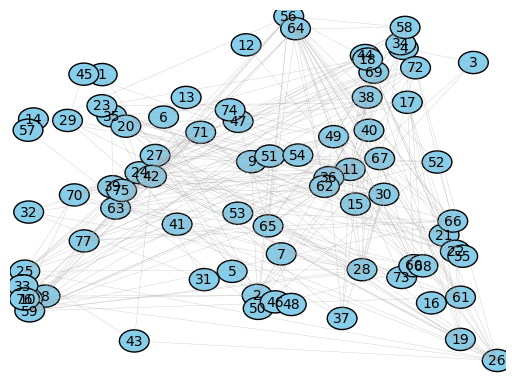

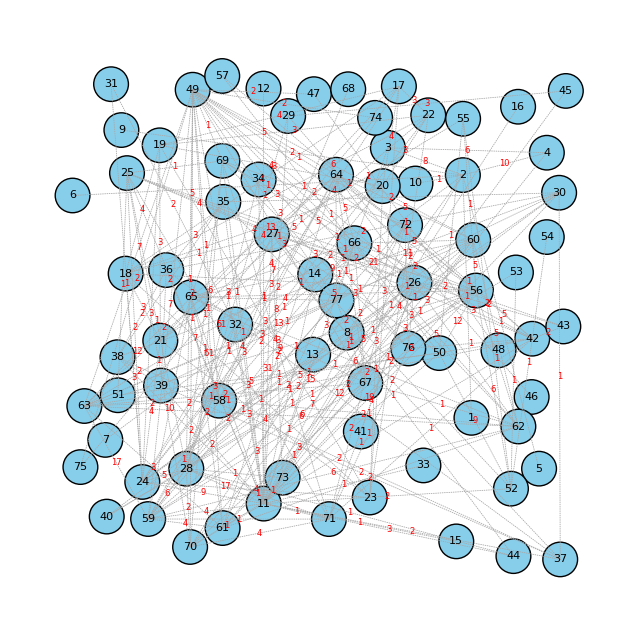

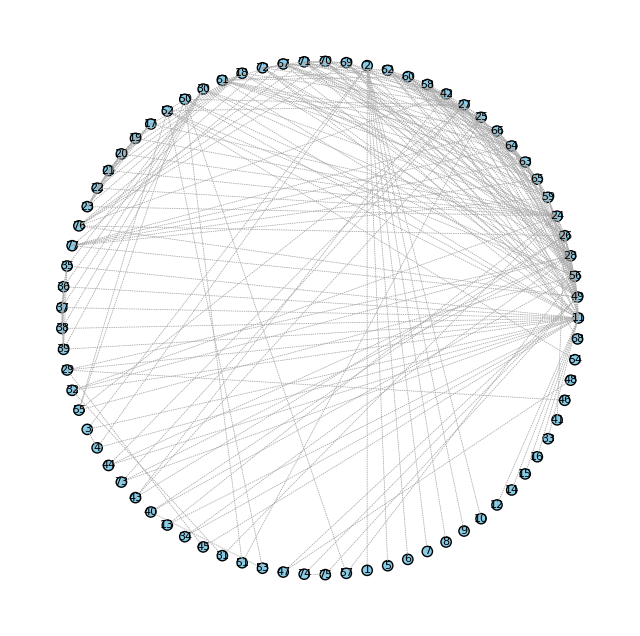

In [6]:
step1(data_name_2)

## step 2

## step 3

In [ ]:
draw_colorful_force_directed_graph_fruchterman_reingold_inertia(
    file_name, 
    iterations=200,
    C=1.75,  
    convergence_threshold=0.001,
    display_node_id=False)

## step 4

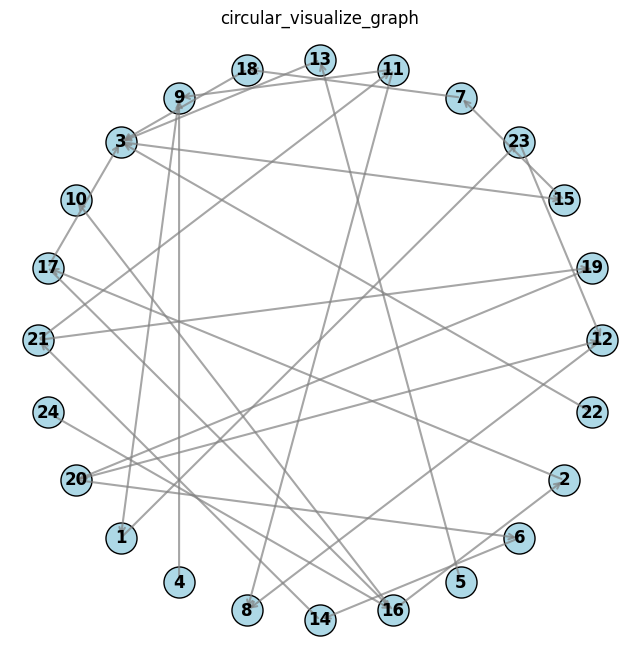

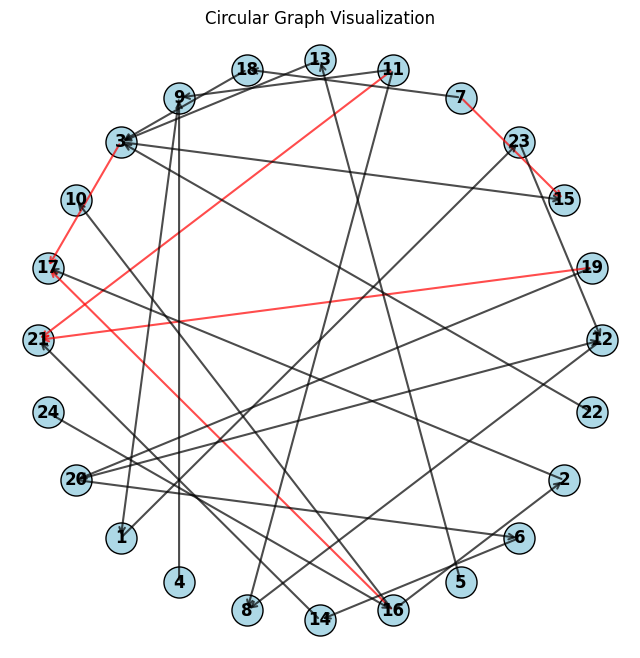

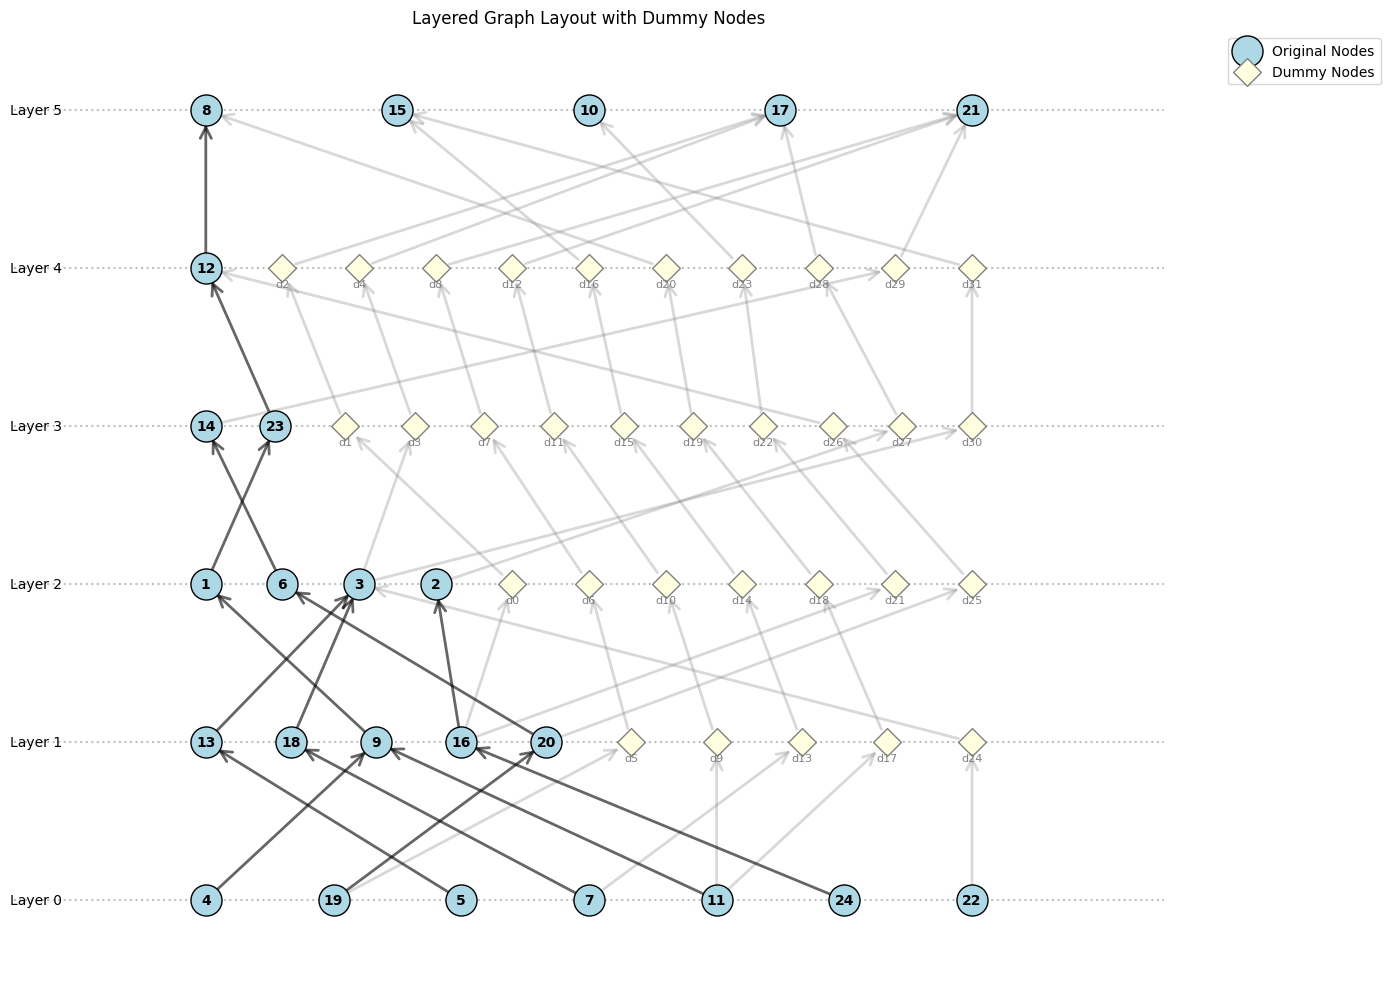

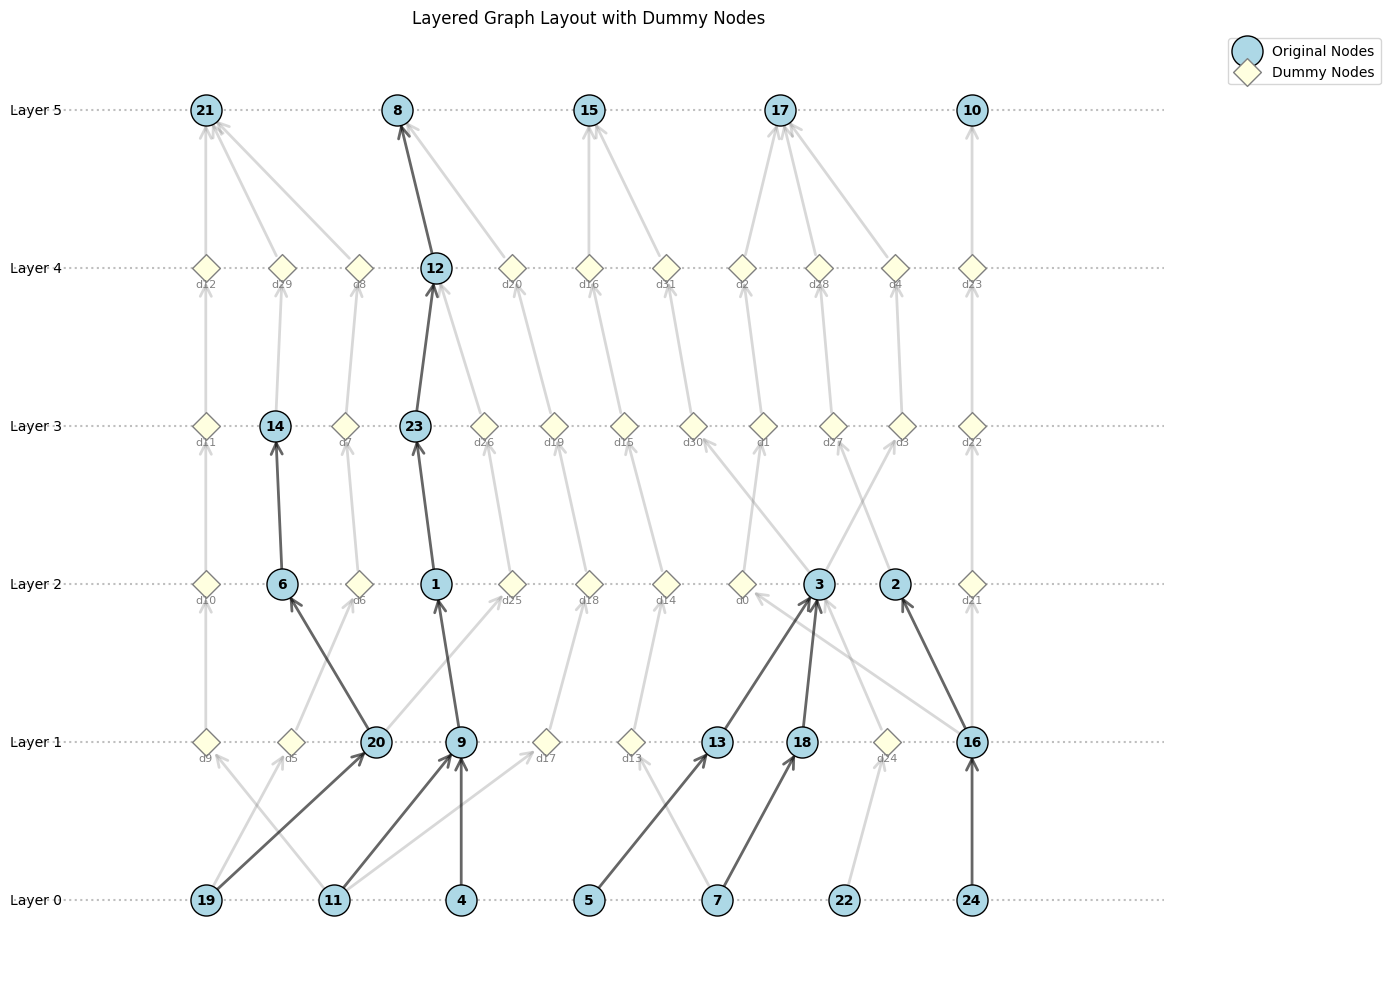

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.14956561666246235
            Iterations: 17
            Function evaluations: 982
            Gradient evaluations: 17


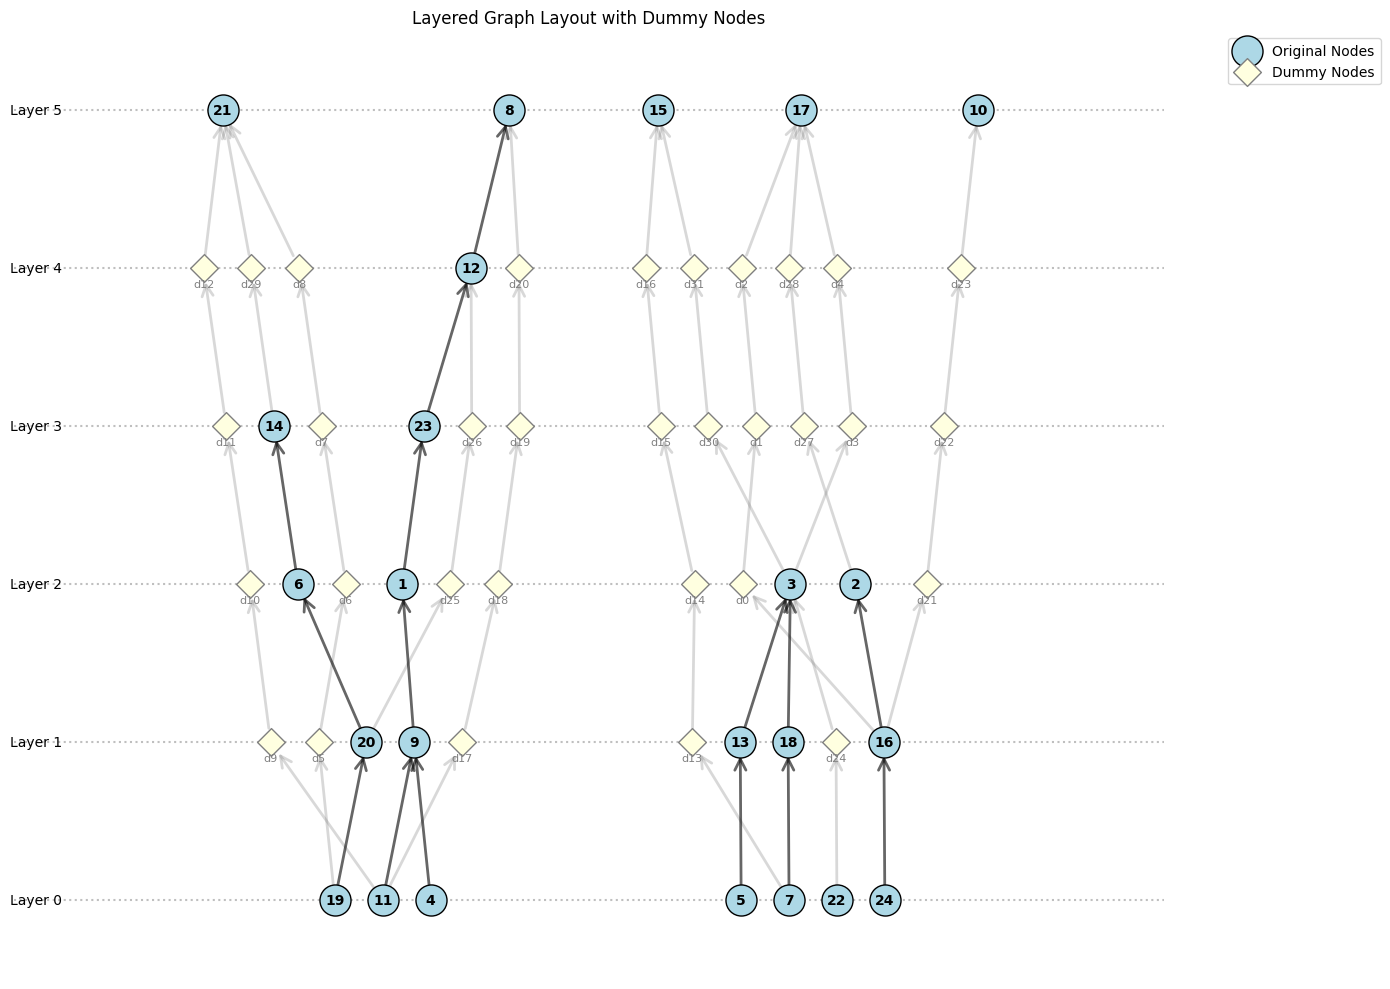

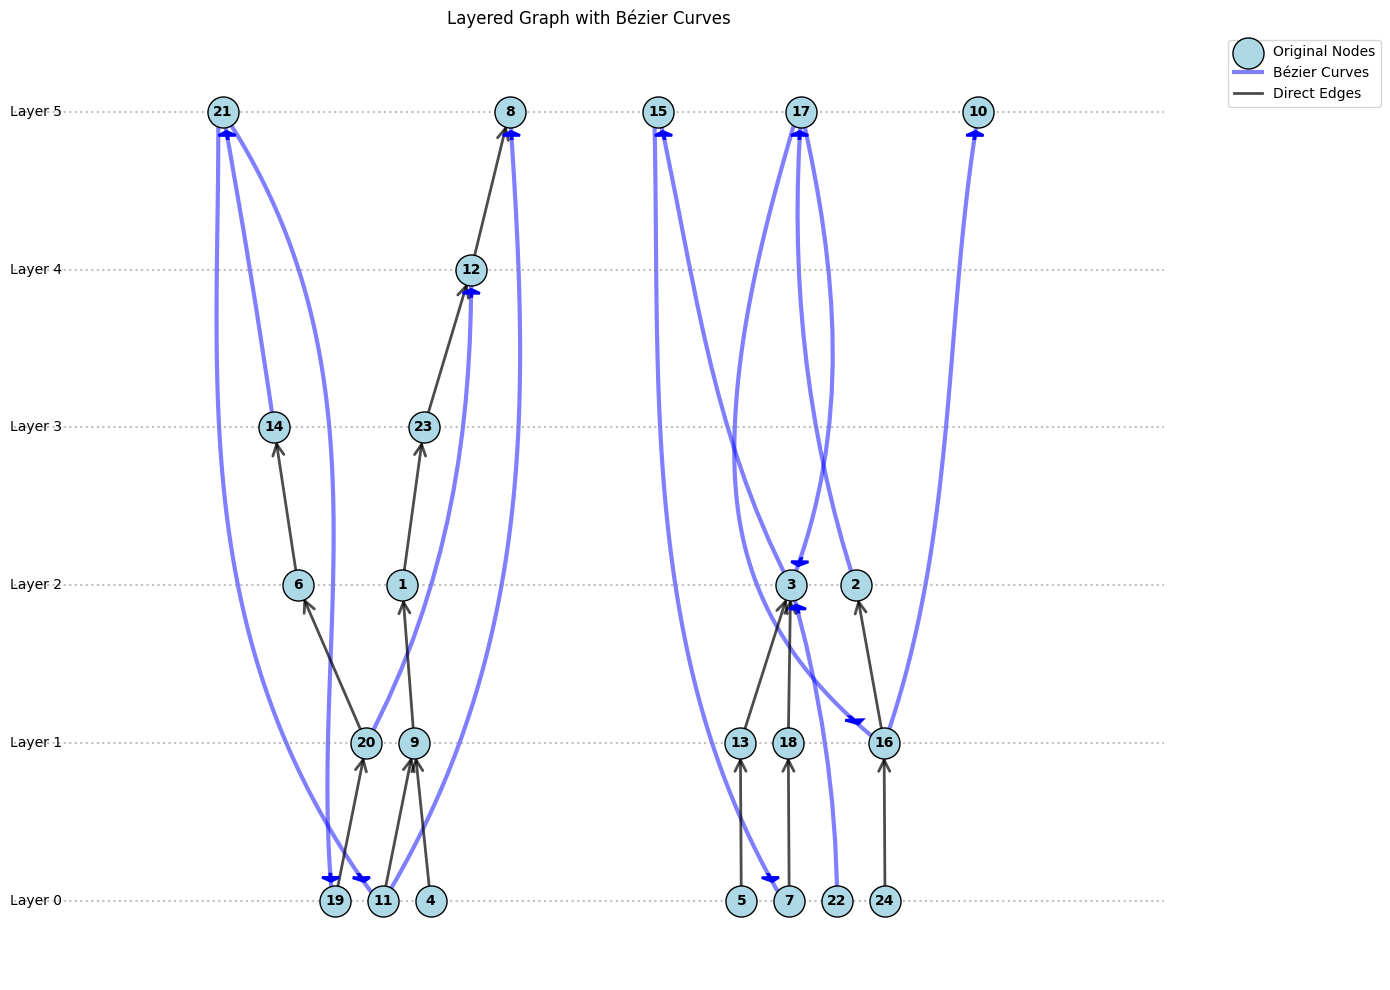

In [3]:
# Circular Layout
def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  
    nodes = set()
    edges = []

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def nodes_edges(nodes, edges):
    print("Nodes: ", nodes)
    print("Edges: ", edges)

    n = set()
    e = []

    for ed in edges:
        # print(ed)
        
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def circular_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("circular_visualize_graph")
    plt.show()

#use a file
dot_file = data_name_9 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)

# Resolve cycles with trivial heuristic

def find_loops(nodes, edges):
    """
    Find all distinct cycles in a directed graph using NetworkX.
    
    Args:
        nodes: List of nodes in the graph
        edges: List of edges as tuples (source, destination)
        
    Returns:
        list: All distinct cycles found in the graph
    """
    # Create a directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    
    # Find all simple cycles
    cycles = list(nx.simple_cycles(G))
    
    return cycles

def reversed_edges(A, A_reverse):
    """Return the reversed edges that solve the loops"""
    A_reversed = [(dst, src) for src, dst in A_reverse]
    final_reversed = A_reversed + A
    
    return final_reversed

def circular_reverse_graph(nodes, edges, E_unchanged=None):
    """
    Plot the directed graph using Matplotlib.
    
    Parameters:
        nodes: List of nodes
        edges: List of all edges
        E_unchanged: List of edges that were not changed (to be drawn in black)
    """
    if E_unchanged is None:
        E_unchanged = []
    
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        
        # Check if edge is in E_unchanged
        if (src, dst) in E_unchanged:
            edge_color = "black"  # Unchanged edges in black
        else:
            edge_color = "red"    # Changed edges in red
            
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=edge_color, lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


    plt.title("Circular Graph Visualization")
    plt.show()

def trivial_feedback_arc_set(nodes, edges):
    """
    Trivial heuristic to find a feedback arc set.
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        A: list of edges to keep as they are
        A_reverse: list of edges to be reversed
    """
    # Create the graph as a dictionary {node: [adjacent_nodes]}
    graph = {node: [] for node in nodes}
    for source, target in edges:
        if source in graph:
            graph[source].append(target)
    
    # Create lists to store the edges
    A = []          # edges to keep
    A_reverse = []  # edges to reverse
    
    # Calculate indegree for each node
    in_degree = {node: 0 for node in graph}
    for node in graph:
        for neighbor in graph[node]:
            if neighbor in in_degree:  # Ensure the node exists in the dictionary
                in_degree[neighbor] = in_degree.get(neighbor, 0) + 1
    
    # Continue until there are no nodes left in the graph
    while graph:
        # Step 1: Find sink and source nodes
        sinks = [node for node in graph if not graph[node]]
        sources = [node for node in graph if in_degree[node] == 0]
        
        # Step 2: Remove sink nodes
        while sinks:
            sink = sinks.pop()
            # Add the incoming edges of the sink to A
            for node in list(graph.keys()):
                if sink in graph[node]:
                    A.append((node, sink))
                    graph[node].remove(sink)
                    in_degree[sink] -= 1
            # Remove the sink node from the graph
            del graph[sink]
        
        # Step 3: Remove isolated nodes
        isolated = [node for node in graph if not graph[node] and in_degree[node] == 0]
        for node in isolated:
            del graph[node]
        
        # Step 4: Remove source nodes
        while sources:
            source = sources.pop()
            # Add the outgoing edges of the source to A
            for neighbor in list(graph[source]):
                A.append((source, neighbor))
                graph[source].remove(neighbor)
                in_degree[neighbor] -= 1
                # Check if the neighbor has become a source
                if in_degree[neighbor] == 0 and neighbor in graph and neighbor not in sources:
                    sources.append(neighbor)
            # Remove the source node from the graph
            del graph[source]
        
        # Step 5: If there are still nodes, select the one with max(outdegree - indegree)
        if graph:
            # Calculate outdegree - indegree for each node
            diff_degree = {node: len(graph[node]) - in_degree[node] for node in graph}
            
            # Find the node with the maximum difference
            max_diff_node = max(diff_degree, key=diff_degree.get)
            
            # Add the node's edges to A_reverse
            for neighbor in list(graph[max_diff_node]):
                A_reverse.append((max_diff_node, neighbor))
                graph[max_diff_node].remove(neighbor)
                in_degree[neighbor] -= 1
            
            # Remove the node from the graph
            del graph[max_diff_node]
    
    return A, A_reverse

#Tesing with LeagueNetwork or noname

dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)

A, A_reverse = trivial_feedback_arc_set(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, final_edges, A) # A Is the list of unchanged edges. The remaining edges have been reversed and coloured in red.
# check on the loops <- skipped because it takes too long
#print(f"list of looping nodes: {find_loops(nodes, final_edges)}")


# Layer Assignment

def find_sources(nodes, edges):
    """
    Find source nodes (nodes with no incoming edges).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        List of source nodes.
    """
    # Create a set of all nodes (from input nodes and those mentioned in edges)
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Initialize incoming edge counts
    incoming_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        incoming_edges[dst] += 1.
    return [node for node, count in incoming_edges.items() if count == 0]

def add_dummy_nodes(layers, edges):
    """
    Add dummy nodes for edges that span multiple layers.
    """
    # Create node to layer mapping
    node_to_layer = {}
    for i, layer in enumerate(layers):
        for node in layer:
            node_to_layer[node] = i
    
    modified_layers = [layer[:] for layer in layers]
    modified_edges = []
    dummy_mapping = {}  # Maps dummy nodes to original edges
    dummy_counter = 0
    
    for source, target in edges:
        source_layer = node_to_layer[source]
        target_layer = node_to_layer[target]
        
        if target_layer - source_layer > 1:
            # Edge spans multiple layers, need dummy nodes
            current = source
            for layer_idx in range(source_layer + 1, target_layer):
                dummy_name = f"dummy_{dummy_counter}"
                dummy_counter += 1
                
                # Add dummy node to layer
                modified_layers[layer_idx].append(dummy_name)
                
                # Add edge to dummy node
                modified_edges.append((current, dummy_name))
                dummy_mapping[dummy_name] = (source, target)
                current = dummy_name
            
            # Connect last dummy node to target
            modified_edges.append((current, target))
        else:
            modified_edges.append((source, target))
    
    return modified_layers, modified_edges, dummy_mapping

def find_sinks(nodes, edges):
    """
    Find sink nodes (nodes with no outgoing edges).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        List of sink nodes.
    """
    # Create a set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Find nodes that appear as sources but not as destinations
    outgoing_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        outgoing_edges[src] += 1
    return [node for node, count in outgoing_edges.items() if count == 0]

def sugiyama_layer_assignment(nodes, edges):
    """
    Enhanced Sugiyama layer assignment with dummy nodes and sink handling.
    """
    # Create a comprehensive set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # First, identify sink nodes
    sink_nodes = set(find_sinks(nodes, edges))
    
    # Remove sink nodes from consideration for initial layering
    working_nodes = all_nodes - sink_nodes
    working_edges = [(src, dst) for src, dst in edges if dst not in sink_nodes]
    
    layers = []  # Stores the final layers
    remaining_nodes = working_nodes.copy()
    remaining_edges = working_edges.copy()

    # Layer assignment for non-sink nodes
    while remaining_nodes:
        sources = find_sources(remaining_nodes, remaining_edges)
        
        if not sources:
            raise ValueError("Graph contains cycles or is disconnected.")
        
        layers.append(sources)
        remaining_nodes -= set(sources)
        remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    # Add sink nodes as the final layer
    if sink_nodes:
        layers.append(list(sink_nodes))
    
    # Add dummy nodes for long edges
    layers_with_dummies, modified_edges, dummy_mapping = add_dummy_nodes(layers, edges)
    
    return layers_with_dummies, modified_edges, dummy_mapping
def draw_layered_graph(layers, edges, dummy_mapping=None):
    """
    Draw the layered graph showing layer structure with dummy nodes.
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Calculate x-positions for nodes in this layer
        num_nodes = len(layer_nodes)
        x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
        
        # Place nodes
        for node_idx, node in enumerate(layer_nodes):
            x = x_positions[node_idx]
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             # Draw arrow using annotate with larger arrows
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  # different arrow style for better visibility
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2,  # increased line width
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions


def count_edge_crossings(positions, edges):
    """
    Count the number of edge crossings in a layered graph and return the crossing edges.
    
    Parameters:
        positions: Dictionary mapping node IDs to (x, y) coordinates
        edges: List of tuples (source_node, target_node) representing edges
    
    Returns:
        tuple: (number of crossings, list of crossing edge pairs)
    """
    def line_segments_intersect(p1, p2, p3, p4):
        """
        Check if line segments (p1, p2) and (p3, p4) intersect.
        Each point is a tuple (x, y).
        """
        def orientation(p, q, r):
            # Calculate orientation of triplet (p, q, r)
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            if val == 0: return 0   # Collinear
            return 1 if val > 0 else 2  # Clockwise or Counterclockwise
        
        def on_segment(p, q, r):
            # Check if point q lies on line segment pr
            return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
                    q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))
        
        # Find orientations
        o1 = orientation(p1, p2, p3)
        o2 = orientation(p1, p2, p4)
        o3 = orientation(p3, p4, p1)
        o4 = orientation(p3, p4, p2)
        
        # General case: different orientations
        if o1 != o2 and o3 != o4:
            return True
        
        # Special cases: collinearity
        if o1 == 0 and on_segment(p1, p3, p2): return True
        if o2 == 0 and on_segment(p1, p4, p2): return True
        if o3 == 0 and on_segment(p3, p1, p4): return True
        if o4 == 0 and on_segment(p3, p2, p4): return True
        
        return False  # No intersection
    
    crossings = 0
    crossing_edges = []
    
    # Check each pair of edges
    for i in range(len(edges)):
        src1, dst1 = edges[i]
        # Skip if we don't have position data for these nodes
        if src1 not in positions or dst1 not in positions:
            continue
            
        p1 = positions[src1]
        p2 = positions[dst1]
        
        for j in range(i+1, len(edges)):
            src2, dst2 = edges[j]
            # Skip if we don't have position data for these nodes
            if src2 not in positions or dst2 not in positions:
                continue
                
            p3 = positions[src2]
            p4 = positions[dst2]
            
            # Check if these edges share an endpoint
            if src1 == src2 or src1 == dst2 or dst1 == src2 or dst1 == dst2:
                continue  # Edges sharing endpoints don't count as crossings
            
            # Check if these line segments intersect
            if line_segments_intersect(p1, p2, p3, p4):
                crossings += 1
                crossing_edges.append(((src1, dst1), (src2, dst2)))
    
    return crossings, crossing_edges

#usage
dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)

A, A_reverse = trivial_feedback_arc_set(nodes, edges)
final_edges = reversed_edges(A, A_reverse)

layers, modified_edges, dummy_mapping  = sugiyama_layer_assignment(nodes, final_edges)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)

# Cross minimization
def get_node_order(layer):
    """Helper function to get the current order of nodes in a layer"""
    return {node: idx for idx, node in enumerate(layer)}

def get_median_position(node, connected_nodes, node_order):
    """Calculate median position for a node based on its connected nodes"""
    if not connected_nodes:
        return float('inf')
    positions = sorted([node_order[n] for n in connected_nodes])
    n = len(positions)
    if n % 2 == 1:
        return positions[n // 2]
    return (positions[(n-1) // 2] + positions[n // 2]) / 2

def get_barycenter_position(node, connected_nodes, node_order):
    """Calculate barycenter position for a node based on its connected nodes"""
    if not connected_nodes:
        return float('inf')
    return sum(node_order[n] for n in connected_nodes) / len(connected_nodes)

def count_crossings(layer1, layer2, edges):
    """Count number of edge crossings between two adjacent layers"""
    crossings = 0
    layer1_order = {node: idx for idx, node in enumerate(layer1)}
    layer2_order = {node: idx for idx, node in enumerate(layer2)}
    
    edges_between = [(s, t) for s, t in edges if s in layer1_order and t in layer2_order]
    for i, (s1, t1) in enumerate(edges_between):
        for s2, t2 in edges_between[i+1:]:
            if (layer1_order[s1] - layer1_order[s2]) * (layer2_order[t1] - layer2_order[t2]) < 0:
                crossings += 1
    return crossings

def count_all_crossings(layers, edges):
    """Count total crossings between all adjacent layers"""
    total = 0
    for i in range(len(layers) - 1):
        total += count_crossings(layers[i], layers[i+1], edges)
    return total

def minimize_crossings(layers, edges, max_iterations=10, method='barycenter'):
    """
    Minimize edge crossings using either barycenter or median heuristic
    Args:
        layers: List of layers, each containing nodes
        edges: List of (source, target) edge tuples
        max_iterations: Maximum number of sweep iterations
        method: 'barycenter' or 'median'
    """
    previous_down_crossings = float('inf')  # Add this line
    previous_up_crossings = float('inf')    # Add this line
    # Create adjacency lists for quick lookup
    successors = {node: [] for layer in layers for node in layer}
    predecessors = {node: [] for layer in layers for node in layer}
    
    for source, target in edges:
        successors[source].append(target)
        predecessors[target].append(source)
    
    position_func = get_barycenter_position if method == 'barycenter' else get_median_position
    
    initial_crossings = count_all_crossings(layers, edges)
    #print(f"\nInitial crossing count: {initial_crossings}")
    #print("-" * 40)
    
    for iteration in range(max_iterations):
        improved = False
        #print(f"\nIteration {iteration + 1}")
        
        # Sweep down
        for i in range(1, len(layers)):
            fixed_order = get_node_order(layers[i-1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, predecessors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        down_crossings = count_all_crossings(layers, edges)
        #print(f"After downward sweep: {down_crossings} crossings")
        
        # Sweep up
        for i in range(len(layers)-2, -1, -1):
            fixed_order = get_node_order(layers[i+1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, successors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        up_crossings = count_all_crossings(layers, edges)
        #print(f"After upward sweep: {up_crossings} crossings")
        
        # Check if pattern repeats (both down and up crossings are same as previous iteration)
        if down_crossings == previous_down_crossings and up_crossings == previous_up_crossings:
            #print("\nPattern repeats (same crossing counts as previous iteration), stopping...")
            break
            
        previous_down_crossings = down_crossings
        previous_up_crossings = up_crossings
        
        if not improved:
            print("\nNo node order changes, stopping...")
            break
    
    final_crossings = count_all_crossings(layers, edges)
    #print(f"\nFinal crossing count: {final_crossings}")
    #print(f"Total reduction: {initial_crossings - final_crossings} crossings")
    
    return layers

def stats_minimize_crossings(layers, edges, max_iterations=10, method='barycenter'):
    """
    Minimize edge crossings using either barycenter or median heuristic
    Args:
        layers: List of layers, each containing nodes
        edges: List of (source, target) edge tuples
        max_iterations: Maximum number of sweep iterations
        method: 'barycenter' or 'median'
    
    Returns:
        tuple: (optimized_layers, crossing_stats)
            - optimized_layers: Layers with minimized crossings
            - crossing_stats: List of dictionaries with crossing counts for each iteration
    """
    previous_down_crossings = float('inf')
    previous_up_crossings = float('inf')
    
    # Create adjacency lists for quick lookup
    successors = {node: [] for layer in layers for node in layer}
    predecessors = {node: [] for layer in layers for node in layer}
    
    for source, target in edges:
        successors[source].append(target)
        predecessors[target].append(source)
    
    position_func = get_barycenter_position if method == 'barycenter' else get_median_position
    
    initial_crossings = count_all_crossings(layers, edges)
    #print(f"\nInitial crossing count: {initial_crossings}")
    #print("-" * 40)
    
    # List to store crossing statistics for each iteration
    crossing_stats = []
    
    for iteration in range(max_iterations):
        improved = False
        print(f"\nIteration {iteration + 1}")
        
        iteration_stats = {
            "iteration": iteration + 1,
            "initial": initial_crossings if iteration == 0 else previous_up_crossings
        }
        
        # Sweep down
        for i in range(1, len(layers)):
            fixed_order = get_node_order(layers[i-1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, predecessors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        down_crossings = count_all_crossings(layers, edges)
        #print(f"After downward sweep: {down_crossings} crossings")
        iteration_stats["down_sweep"] = down_crossings
        
        # Sweep up
        for i in range(len(layers)-2, -1, -1):
            fixed_order = get_node_order(layers[i+1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, successors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        up_crossings = count_all_crossings(layers, edges)
        #print(f"After upward sweep: {up_crossings} crossings")
        iteration_stats["up_sweep"] = up_crossings
        
        # Calculate crossings reduced in this iteration
        crossings_reduced = iteration_stats["initial"] - up_crossings
        iteration_stats["crossings_reduced"] = crossings_reduced
        
        # Add stats to the list
        crossing_stats.append(iteration_stats)
        
        # Check if pattern repeats
        if down_crossings == previous_down_crossings and up_crossings == previous_up_crossings:
            #print("\nPattern repeats (same crossing counts as previous iteration), stopping...")
            break
            
        previous_down_crossings = down_crossings
        previous_up_crossings = up_crossings
        
        if not improved:
            #print("\nNo node order changes, stopping...")
            break
    
    final_crossings = count_all_crossings(layers, edges)
    #print(f"\nFinal crossing count: {final_crossings}")
    #print(f"Total reduction: {initial_crossings - final_crossings} crossings")
    
    # Add total summary to the stats
    crossing_stats.append({
        "iteration": "final",
        "initial": initial_crossings,
        "final": final_crossings,
        "total_reduction": initial_crossings - final_crossings
    })
    
    return crossing_stats

#usage
#apply the crossing minimization to the LeagueNetwork or noname network

layers, modified_edges, dummy_mapping = sugiyama_layer_assignment(nodes, final_edges)

# Apply crossing minimization
optimized_layers = minimize_crossings(
    layers=layers.copy(),  # Create a copy to preserve original
    edges=modified_edges,
    max_iterations=10,
    method='barycenter'  # or 'median'
)

# Visualize the result
positions = draw_layered_graph(optimized_layers, modified_edges, dummy_mapping)
plt.show()


#node postioning

def build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=None):
    """
    For each node in layer 0, find ALL possible paths (u, d1, ..., dk, v) where:
    - u is a node in layer 0
    - d1, ..., dk are nodes (dummy or regular) along the path
    - v is any reachable node with no outgoing edges
    
    Parameters:
        positions: Dictionary mapping node IDs to (x, y) coordinates
        modified_edges: List of edges including dummy nodes
        dummy_mapping: Dictionary mapping dummy nodes to (source, target) tuples
        max_depth: Maximum path length (None for unlimited)
    
    Returns:
        List of paths, where each path is a dictionary with path information
    """
    import collections
    
    # Identify nodes in layer 0
    layer_0_nodes = [node for node, (_, y) in positions.items() if int(y) == 0]
    #print(f"Found {len(layer_0_nodes)} nodes in layer 0")
    
    # Build adjacency list from modified edges
    graph = collections.defaultdict(list)
    for src, dst in modified_edges:
        graph[src].append(dst)
    
    # Identify dummy nodes
    dummy_nodes = set(dummy_mapping.keys())
    
    # Get the layer for each node (will be used to ensure we only go forward)
    node_layers = {node: int(y) for node, (_, y) in positions.items()}
    
    # Track all found paths
    all_paths = []
    
    # DFS to find all paths from a source node
    def find_all_paths(source, current_path=None, visited=None):
        if current_path is None:
            current_path = [source]
        if visited is None:
            visited = set([source])
        
        # Check if we've reached maximum depth
        if max_depth is not None and len(current_path) >= max_depth:
            # Add the path if it has at least one edge
            if len(current_path) > 1:
                all_paths.append({
                    "source": current_path[0],
                    "target": current_path[-1],
                    "path": current_path.copy(),
                    "dummy_nodes": [n for n in current_path if n in dummy_nodes],
                    "length": len(current_path)
                })
            return
        
        # Check if this is a sink node (no outgoing edges)
        if not graph[current_path[-1]]:
            # We've reached the end of a path
            if len(current_path) > 1:  # Only add paths with at least one edge
                all_paths.append({
                    "source": current_path[0],
                    "target": current_path[-1],
                    "path": current_path.copy(),
                    "dummy_nodes": [n for n in current_path if n in dummy_nodes],
                    "length": len(current_path)
                })
            return
        
        # Current node and its layer
        current_node = current_path[-1]
        current_layer = node_layers[current_node]
        
        # Explore all neighbors
        for neighbor in graph[current_node]:
            # Skip if already visited (avoid cycles)
            if neighbor in visited:
                continue
            
            # Only go forward in layers to maintain DAG property
            if node_layers.get(neighbor, float('inf')) <= current_layer:
                continue
            
            # Add neighbor to path
            current_path.append(neighbor)
            visited.add(neighbor)
            
            # Recursively find all paths from neighbor
            find_all_paths(source, current_path, visited)
            
            # Backtrack
            current_path.pop()
            visited.remove(neighbor)
    
    # Process each layer 0 node
    for i, node in enumerate(layer_0_nodes):
        #print(f"Finding paths from node {node} ({i+1}/{len(layer_0_nodes)})")
        find_all_paths(node)
    
    # Sort paths by length (longest first)
    all_paths.sort(key=lambda x: x["length"], reverse=True)
    
    #print(f"Found {len(all_paths)} total paths from layer 0 nodes")
    return all_paths



# Build ALL paths from layer 0 nodes
paths = build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=10)

def compute_ideal_path_positions_by_formula(paths, positions):
    """
    For each path, compute the ideal x-coordinate for each node that would
    make the path perfectly straight using the formula:
    X(i)_ideal = X(u) + (i/len(path)) * (X(v) - X(u))
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
    
    Returns:
        Dictionary with path analysis and ideal positions for each node
    """
    import numpy as np
    
    #print("Computing ideal positions for all nodes in paths using the specified formula...")
    
    # Dictionary to store results for each path
    path_results = {}
    
    # Process each path
    for path_idx, path_info in enumerate(paths):
        path = path_info['path']
        path_length = len(path)
        
        # Skip paths that are too short
        if path_length <= 2:
            continue
            
        # Get source and target nodes
        source_node = path[0]
        target_node = path[-1]
        
        # Get their x-coordinates
        source_x = positions[source_node][0]
        target_x = positions[target_node][0]
        
        # Calculate the x-span
        x_span = target_x - source_x
        
        # Store analysis for each node in this path
        node_positions = []
        total_deviation = 0
        
        for i, node in enumerate(path):
            # Calculate ideal position using the formula:
            # X(i)_ideal = X(u) + (i/len(path)) * (X(v) - X(u))
            t = i / path_length
            ideal_x = source_x + t * x_span
            
            # Calculate deviation from current position
            current_x = positions[node][0]
            deviation = (current_x - ideal_x) ** 2
            total_deviation += deviation
            
            # Store analysis for this node
            node_positions.append({
                'node': node,
                'position': i,
                'current_x': current_x,
                'ideal_x': ideal_x,
                'deviation': deviation
            })
        
        # Store results for this path
        path_results[path_idx] = {
            'source': source_node,
            'target': target_node,
            'path_length': path_length,
            'x_span': x_span,
            'node_positions': node_positions,
            'total_deviation': total_deviation,
            'average_deviation': total_deviation / path_length
        }
    
    # Calculate overall statistics
    all_deviations = [
        node_info['deviation'] 
        for path_info in path_results.values() 
        for node_info in path_info['node_positions']
    ]
    
    overall_stats = {
        'total_paths': len(path_results),
        'total_nodes_analyzed': len(all_deviations),
        'total_deviation': sum(all_deviations),
        'average_deviation': np.mean(all_deviations) if all_deviations else 0,
        'max_deviation': max(all_deviations) if all_deviations else 0
    }
    
    #print(f"Analyzed {overall_stats['total_paths']} paths with {overall_stats['total_nodes_analyzed']} nodes")
    #print(f"Total squared deviation: {overall_stats['total_deviation']:.4f}")
    
    return {
        'paths': path_results,
        'stats': overall_stats
    }

def calculate_path_deviations(paths, positions):
    """
    For each path, calculate the total deviation of all nodes from their ideal positions
    that would make the path perfectly straight.
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
    
    Returns:
        Dictionary with path deviations and details
    """
    import numpy as np
    
    #print("Calculating total deviation from straight lines for each path...")
    
    # Dictionary to store results
    path_deviations = {}
    
    # Process each path
    for path_idx, path_info in enumerate(paths):
        path = path_info['path']
        path_length = len(path)
        
        # Skip paths that are too short
        if path_length <= 2:
            continue
            
        # Get source and target nodes
        source_node = path[0]
        target_node = path[-1]
        
        # Get their x-coordinates
        source_x = positions[source_node][0]
        target_x = positions[target_node][0]
        
        # Calculate total deviation for this path (excluding source node)
        total_deviation = 0
        node_deviations = []
        
        # Skip the first node (source) as specified, start from i=1
        for i, node in enumerate(path[1:], 1):
            # Calculate ideal position using the formula:
            # X(i)_ideal = X(u) + (i/len(path)) * (X(v) - X(u))
            t = i / (path_length - 1)  # Normalized position (0 to 1)
            ideal_x = source_x + t * (target_x - source_x)
            
            # Calculate squared deviation from current position
            current_x = positions[node][0]
            deviation = (current_x - ideal_x) ** 2
            total_deviation += deviation
            
            # Store details for this node
            node_deviations.append({
                'node': node,
                'position': i,
                'current_x': current_x,
                'ideal_x': ideal_x,
                'deviation': deviation
            })
        
        # Store results for this path
        path_deviations[path_idx] = {
            'source': source_node,
            'target': target_node,
            'path': path,
            'path_length': path_length,
            'total_deviation': total_deviation,
            'node_deviations': node_deviations,
            'max_node_deviation': max([n['deviation'] for n in node_deviations]) if node_deviations else 0
        }
    
    # Calculate overall statistics
    sorted_paths = sorted(
        path_deviations.items(), 
        key=lambda x: x[1]['total_deviation'], 
        reverse=True
    )
    
    """print(f"Analyzed {len(path_deviations)} paths")
    print(f"Path with highest deviation: {sorted_paths[0][1]['source']} → {sorted_paths[0][1]['target']} "
          f"(deviation: {sorted_paths[0][1]['total_deviation']:.4f})")"""
    
    return {
        'path_deviations': path_deviations,
        'sorted_paths': sorted_paths
    }

def straighten_paths_quadratic_program(paths, positions, dummy_mapping, min_distance=0.05, max_iterations=500):
    """
    Use quadratic programming to minimize the total deviation of paths from straight lines,
    with integrated deviation calculations during the optimization process.
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
        dummy_mapping: Dictionary mapping dummy nodes to (source, target) tuples
        min_distance: Minimum horizontal distance between consecutive nodes on same layer
        max_iterations: Maximum number of iterations for the optimizer
    
    Returns:
        Dictionary with new optimized positions
    """
    
    #print("Optimizing node positions to straighten paths...")
    
    # Group nodes by layer
    layers = defaultdict(list)
    for node, (x, y) in positions.items():
        layer = int(y)
        layers[layer].append(node)
    
    # Sort nodes within each layer by x-coordinate
    for layer in layers:
        layers[layer].sort(key=lambda node: positions[node][0])
    
    # Create a mapping from node names to indices in the optimization vector
    nodes_list = sorted(positions.keys(), key=lambda node: (positions[node][1], positions[node][0]))
    node_indices = {node: i for i, node in enumerate(nodes_list)}
    
    #print(f"Preparing optimization for {len(nodes_list)} nodes across {len(layers)} layers")
    
    # Define a function to calculate current positions from x-values vector
    def get_positions_from_x_values(x_values):
        current_positions = {}
        for node, idx in node_indices.items():
            _, y = positions[node]  # Keep original y-coordinate
            current_positions[node] = (x_values[idx], y)
        return current_positions
    
    # Define a function to calculate path deviations based on positions
    def calculate_deviations(current_positions):
        path_deviations = OrderedDict()
        
        for path_idx, path_info in enumerate(paths):
            path = path_info['path']
            if len(path) <= 2:
                continue
                
            source_node = path[0]
            target_node = path[-1]
            source_x = current_positions[source_node][0]
            target_x = current_positions[target_node][0]
            
            total_deviation = 0
            node_deviations = []
            
            for i, node in enumerate(path[1:], 1):
                t = i / (len(path) - 1)
                ideal_x = source_x + t * (target_x - source_x)
                
                current_x = current_positions[node][0]
                deviation = (current_x - ideal_x) ** 2
                total_deviation += deviation
                
                node_deviations.append({
                    'node': node,
                    'deviation': deviation
                })
            
            path_deviations[path_idx] = {
                'total_deviation': total_deviation,
                'node_deviations': node_deviations
            }
        
        # Calculate total deviation across all paths
        total_deviation = sum(p['total_deviation'] for p in path_deviations.values())
        return total_deviation, path_deviations
    
    # Objective function for the optimizer
    def objective(x_values):
        # Get current positions from x_values
        current_positions = get_positions_from_x_values(x_values)
        
        # Calculate total deviation
        total_deviation, _ = calculate_deviations(current_positions)
        
        # Add small regularization term to maintain stability
        reg_weight = 0.1
        reg_term = 0
        for i, node in enumerate(nodes_list):
            orig_x = positions[node][0]
            new_x = x_values[i]
            reg_term += reg_weight * (new_x - orig_x) ** 2
            
        return total_deviation + reg_term
    
    # Create constraints for minimum distance between consecutive nodes in same layer
    constraints = []
    for layer, layer_nodes in layers.items():
        for i in range(len(layer_nodes) - 1):
            left_node = layer_nodes[i]
            right_node = layer_nodes[i + 1]
            
            # Constraint: right_node.x - left_node.x >= min_distance
            constraints.append({
                'type': 'ineq',
                'fun': lambda x, i1=node_indices[left_node], i2=node_indices[right_node]: 
                       x[i2] - x[i1] - min_distance
            })
    
    #print(f"Created {len(constraints)} ordering constraints")
    
    # Initial values = current x-coordinates
    x0 = [positions[node][0] for node in nodes_list]
    
    # Calculate initial deviation for comparison
    initial_positions = positions.copy()
    initial_total_deviation, initial_path_deviations = calculate_deviations(initial_positions)
    #print(f"Initial total deviation: {initial_total_deviation:.4f}")
    
    # Set bounds to prevent extreme movement
    min_x = min(pos[0] for pos in positions.values())
    max_x = max(pos[0] for pos in positions.values())
    margin = 0.2 * (max_x - min_x)  # Allow 20% margin on each side
    bounds = [(min_x - margin, max_x + margin) for _ in range(len(x0))]
    
    # Callback to monitor progress
    iteration_data = {'iterations': 0, 'best_deviation': initial_total_deviation}
    
    def callback(x):
        iteration_data['iterations'] += 1
        if iteration_data['iterations'] % 10 == 0:  # Report every 10 iterations
            current_positions = get_positions_from_x_values(x)
            current_deviation, _ = calculate_deviations(current_positions)
            improvement = (initial_total_deviation - current_deviation) / initial_total_deviation * 100
            
            if current_deviation < iteration_data['best_deviation']:
                iteration_data['best_deviation'] = current_deviation
                
            """print(f"Iteration {iteration_data['iterations']}: "
                  f"Deviation = {current_deviation:.4f} "
                  f"(Improved by {improvement:.2f}%)")"""
    
    #print("Starting optimization...")
    
    # Solve the optimization problem
    try:
        result = optimize.minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            callback=callback,
            options={
                'disp': True,
                'maxiter': max_iterations,
                'ftol': 1e-6
            }
        )
        
        if result.success:
            #print(f"Optimization succeeded: {result.message}")
            
            # Create new positions with optimized x-coordinates
            new_positions = get_positions_from_x_values(result.x)
            
            # Calculate final deviation metrics
            final_total_deviation, final_path_deviations = calculate_deviations(new_positions)
            
            # Calculate improvement
            improvement = (initial_total_deviation - final_total_deviation) / initial_total_deviation * 100
            
            # Count moved nodes
            moved_nodes = 0
            for node in nodes_list:
                if abs(positions[node][0] - new_positions[node][0]) > 0.0001:
                    moved_nodes += 1
            
            #print(f"Moved {moved_nodes} out of {len(nodes_list)} nodes")
            
            # Identify paths with greatest improvement
            path_improvements = []
            for path_idx in initial_path_deviations:
                if path_idx in final_path_deviations:
                    initial_dev = initial_path_deviations[path_idx]['total_deviation']
                    final_dev = final_path_deviations[path_idx]['total_deviation']
                    path_improvements.append((
                        path_idx,
                        initial_dev - final_dev,
                        (initial_dev - final_dev) / initial_dev * 100 if initial_dev > 0 else 0
                    ))
            
            # Sort by absolute improvement amount
            path_improvements.sort(key=lambda x: x[1], reverse=True)
            
            
            # Verify layer ordering is maintained
            for layer, nodes in layers.items():
                sorted_nodes = sorted(nodes, key=lambda n: new_positions[n][0])
                if sorted_nodes != nodes:
                    print(f"Warning: Node ordering changed in layer {layer}")
            
            return new_positions
            
        else:
            print(f"Optimization failed: {result.message}")
            return positions
            
    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return positions

# First get all paths
paths = build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=10)

# Optimize positions to straighten paths
optimized_positions = straighten_paths_quadratic_program(
    paths, 
    positions, 
    dummy_mapping, 
    min_distance=0.05,
    max_iterations=300
)

def positions_draw_layered_graph(layers, edges, dummy_mapping=None, new_positions=None):
    """
    Draw the layered graph showing layer structure with dummy nodes.
    Optional: Use pre-calculated x-coordinates from new_positions
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Place nodes - modified to use new_positions when available
        for node_idx, node in enumerate(layer_nodes):
            # Get x-coordinate - either from new_positions or calculate it
            if new_positions and node in new_positions:
                # Use provided x-coordinate
                x = new_positions[node][0]
            else:
                # Fall back to calculated positions
                num_nodes = len(layer_nodes)
                x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
                x = x_positions[node_idx]
                
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             # Draw arrow using annotate with larger arrows
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  # different arrow style for better visibility
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2,  # increased line width
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    if not new_positions:
        return node_positions

#usage
positions_draw_layered_graph(optimized_layers, modified_edges, dummy_mapping, optimized_positions)

# Edge reversing & drawing

def positions_draw_layered_graph_with_bezier(new_positions, layers, edges, dummy_mapping, original_edges=None, show_dummies=False):
    """
    Draw the layered graph showing Bézier curves with optional display of dummy nodes.
    
    Parameters:
        layers: List of lists representing node ordering in each layer
        edges: List of edges including dummy edges
        dummy_mapping: Dictionary mapping dummy nodes to original edges
        original_edges: List of original edges to determine direction (optional)
        show_dummies: Whether to show dummy nodes and their connecting edges (default: False)
    
    Returns:
        Dictionary of node positions
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Place nodes - modified to use new_positions when available
        for node_idx, node in enumerate(layer_nodes):
            # Get x-coordinate - either from new_positions or calculate it
            if new_positions and node in new_positions:
                # Use provided x-coordinate
                x = new_positions[node][0]
            else:
                # Fall back to calculated positions
                num_nodes = len(layer_nodes)
                x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
                x = x_positions[node_idx]
                
            y = y_position
            node_positions[node] = (x, y)

            is_dummy = node in dummy_mapping
            
            # Draw node if it's a real node or if show_dummies is True
            if not is_dummy or show_dummies:
                node_color = 'lightyellow' if is_dummy else 'lightblue'
                node_size = 200 if is_dummy else 500
                node_shape = 'D' if is_dummy else 'o'
                
                plt.scatter(x, y, s=node_size, color=node_color, 
                          edgecolor='gray' if is_dummy else 'black', 
                          marker=node_shape, zorder=3)
                
                # Node labels
                if is_dummy:
                    if show_dummies:
                        plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                                va='center', fontsize=8, color='gray')
                else:
                    plt.text(x, y, node, ha='center', va='center', 
                            fontweight='bold', zorder=4)
    
    # Group dummy nodes by their original edge
    edge_paths = {}
    for dummy, (src, dst) in dummy_mapping.items():
        if (src, dst) not in edge_paths:
            edge_paths[(src, dst)] = []
        edge_paths[(src, dst)].append(dummy)
    
    # Sort dummy nodes for each edge by their layer
    for edge, dummies in edge_paths.items():
        dummies.sort(key=lambda d: node_positions[d][1] if d in node_positions else 0)
    
    # Draw direct edges (those not involving dummy nodes)
    for src, dst in edges:
        if src not in dummy_mapping and dst not in dummy_mapping:
            if src in node_positions and dst in node_positions:
                x_src, y_src = node_positions[src]
                x_dst, y_dst = node_positions[dst]
                
                # Draw direct edge
                plt.annotate('', 
                    xy=(x_dst, y_dst),
                    xytext=(x_src, y_src),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='black',
                        alpha=0.7,
                        connectionstyle='arc3,rad=0',
                        linewidth=2,
                        mutation_scale=20,
                        shrinkA=10,
                        shrinkB=10
                    ),
                    zorder=2
                )
    
    # Draw dummy edges if requested
    if show_dummies:
        for src, dst in edges:
            if (src in dummy_mapping or dst in dummy_mapping) and src in node_positions and dst in node_positions:
                x_src, y_src = node_positions[src]
                x_dst, y_dst = node_positions[dst]
                
                # Draw dummy edge
                plt.annotate('', 
                    xy=(x_dst, y_dst),
                    xytext=(x_src, y_src),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='gray',
                        alpha=0.4,
                        connectionstyle='arc3,rad=0',
                        linewidth=1.5,
                        mutation_scale=15,
                        shrinkA=10,
                        shrinkB=10
                    ),
                    zorder=1
                )
    
    # Import required libraries
    from matplotlib.path import Path
    import matplotlib.patches as patches
    from scipy.interpolate import splprep, splev
    
    # Draw smoothed Bézier curves for edges with dummy nodes
    for (src, dst), dummies in edge_paths.items():
        if src in node_positions and dst in node_positions:
            # Check if direction should be reversed based on original edges
            reverse_direction = False
            if original_edges is not None:
                src_dst_in_original = (src, dst) in original_edges
                dst_src_in_original = (dst, src) in original_edges
                
                if dst_src_in_original and not src_dst_in_original:
                    reverse_direction = True
            
            # Get path points with correct direction
            if reverse_direction:
                path_nodes = [dst] + list(reversed(dummies)) + [src]
                path_points = [node_positions[node] for node in path_nodes if node in node_positions]
            else:
                path_nodes = [src] + dummies + [dst]
                path_points = [node_positions[node] for node in path_nodes if node in node_positions]
            
            # Need at least start and end points
            if len(path_points) < 2:
                continue
            
            # For simple paths with few points, use standard Bézier curves
            if len(path_points) <= 4:
                points = np.array(path_points)
                
                if len(points) == 2:
                    # Simple line for just source and target
                    codes = [Path.MOVETO, Path.LINETO]
                    
                elif len(points) == 3:
                    # Quadratic Bézier for source, one dummy, and target
                    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
                    
                elif len(points) == 4:
                    # Cubic Bézier for source, two dummies, and target
                    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
                
                # Create and draw the path
                path = Path(points, codes)
                patch = patches.PathPatch(path, facecolor='none', edgecolor='blue', 
                                         lw=3, alpha=0.5, zorder=1)
                plt.gca().add_patch(patch)
                
                # Get interpolated points along the curve for arrow placement
                interpolated = path.interpolated(50).vertices
                
            # For complex paths with many points, use smooth spline interpolation
            else:
                # Convert to numpy array
                points = np.array(path_points)
                
                # Use scipy's spline representation for a smoother curve
                try:
                    # Parameterize with more points for smoother curves
                    # s=0 means no smoothing, but we'll add a small value for smoother curves
                    tck, u = splprep([points[:, 0], points[:, 1]], s=0.001)
                    
                    # Create more points along the spline
                    u_new = np.linspace(0, 1, 100)
                    x_new, y_new = splev(u_new, tck)
                    
                    # Draw the smoothed curve
                    plt.plot(x_new, y_new, '-', color='blue', lw=3, alpha=0.5, zorder=1)
                    
                    # Save points for arrow placement
                    interpolated = np.column_stack([x_new, y_new])
                    
                except Exception:
                    # Fallback to piecewise linear if spline fails
                    plt.plot(points[:, 0], points[:, 1], '-', color='blue', lw=3, alpha=0.5, zorder=1)
                    interpolated = points
            
            # Add arrow near the end, following the curve's direction
            if len(interpolated) >= 2:
                # Get points near the end for proper direction along curve
                end_idx = len(interpolated) - 1
                dir_idx = max(0, end_idx - 5)  # 5 points from the end for direction
                
                end = interpolated[end_idx]
                before_end = interpolated[dir_idx]
                
                # Calculate direction and normalize
                direction = end - before_end
                length = np.sqrt(np.sum(direction**2))
                if length > 0:
                    direction = direction / length
                    
                    # Calculate position for arrow that's offset from the target node
                    node_radius = 0.15  # Approximate radius of the node
                    arrow_pos = end - direction * node_radius
                    
                    # Draw larger arrow head
                    arrow_size = 0.01
                    plt.arrow(arrow_pos[0] - direction[0]*arrow_size*2, 
                             arrow_pos[1] - direction[1]*arrow_size*2,
                             direction[0]*arrow_size*2, direction[1]*arrow_size*2,
                             head_width=arrow_size*1.8,  # Wider arrow head
                             head_length=arrow_size*2.5, # Longer arrow head
                             fc='blue', ec='blue', zorder=2,
                             linewidth=2)  # Thicker line
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    
    if show_dummies:
        plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
                   marker='D', label='Dummy Nodes')
        plt.plot([], [], color='gray', lw=1.5, alpha=0.4, label='Dummy Edges')
        
    plt.plot([], [], 'b-', lw=3, alpha=0.5, label='Bézier Curves')
    plt.plot([], [], 'k-', lw=2, alpha=0.7, label='Direct Edges')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    title = 'Layered Graph with Bézier Curves'
    if show_dummies:
        title += ' and Dummy Nodes'
    plt.title(title)
    
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions

#usage
# Usage example:
positions = positions_draw_layered_graph_with_bezier(
    optimized_positions,
    optimized_layers, 
    modified_edges, 
    dummy_mapping,
    original_edges=edges,  # Pass original edges to determine direction
    show_dummies=False  # Set to True to show dummy nodes
)
plt.show()

## step 5

## step 6

### distance matrix

### mds

### t-sne

### isomap

## step 7